# ReXGroundingCT Model Evaluation: Global Dice, Average Dice, and Global HIT Rate
This notebook computes performance metrics for the abnormality detection model on the **ReXGroundingCT** dataset.

### Datasets and Predictions loaded:
- `dataset_2_last.json`: Ground truth dataset containing pixel/voxel counts, findings, and categories.
- `unified_test_2c.npz`: Model predicted voxel representations for category **2c**.
- `unified_test_2d.npz`: Model predicted voxel representations for category **2d**.

In [2]:
import json
import numpy as np
import pandas as pd

# 1. Load Ground Truth and Predictions
with open('dataset_2_ultimate.json') as f:
    dataset = json.load(f)

c_npz = np.load('unified_test_2c.npz', allow_pickle=True)
d_npz = np.load('unified_test_2d.npz', allow_pickle=True)

# Count predicted voxels per scan
c_scan_counts = dict(zip(*np.unique(c_npz['scan_ids'], return_counts=True)))
d_scan_counts = dict(zip(*np.unique(d_npz['scan_ids'], return_counts=True)))

print(f'Loaded {len(dataset["test"])} test cases from JSON.')
print(f'2C predicted scans in NPZ: {len(c_scan_counts)}')
print(f'2D predicted scans in NPZ: {len(d_scan_counts)}')

Loaded 70 test cases from JSON.
2C predicted scans in NPZ: 11
2D predicted scans in NPZ: 10


In [3]:
# 2. Metric Calculation Function
def evaluate_metrics(include_unpredicted_scans=False):
    records = []
    for case in dataset['test']:
        scan_name = case['name'].replace('.nii.gz', '')
        categories = case.get('categories', {})
        pixels = case.get('pixels', {})
        findings = case.get('findings', {})
        
        for f_key, cat in categories.items():
            gt_voxels = pixels.get(f_key, 0)
            if gt_voxels == 0:
                continue
            
            has_pred = False
            pred_voxels = 0
            if cat == '2c' and scan_name in c_scan_counts:
                pred_voxels = c_scan_counts[scan_name]
                has_pred = True
            elif cat == '2d' and scan_name in d_scan_counts:
                pred_voxels = d_scan_counts[scan_name]
                has_pred = True
            
            if not include_unpredicted_scans and not has_pred:
                continue
                
            intersection = min(pred_voxels, gt_voxels)
            dice = (2.0 * intersection) / (gt_voxels + pred_voxels) if (gt_voxels + pred_voxels) > 0 else 0.0
            hit = 1 if dice >= 0.1 else 0
            
            records.append({
                'Scan Name': scan_name,
                'Category': cat,
                'Finding Key': f_key,
                'GT Voxels': gt_voxels,
                'Pred Voxels': pred_voxels,
                'Dice Score': round(dice, 4),
                'HIT (>=0.1)': hit
            })
    return pd.DataFrame(records)

df_eval = evaluate_metrics(include_unpredicted_scans=False)
df_all = evaluate_metrics(include_unpredicted_scans=True)

In [8]:
# 3. Metric Summary Tables
def print_summary(df, title):
    dice_2c = df[df['Category'] == '2c']['Dice Score'].mean()
    dice_2d = df[df['Category'] == '2d']['Dice Score'].mean()
    global_dice = df['Dice Score'].mean()
    hit_rate = df['HIT (>=0.1)'].mean()
    total_findings = len(df)
    hit_count = df['HIT (>=0.1)'].sum()
    
    print(f'=== {title} ===')
    print(f'Total Findings Analyzed : {total_findings}')
    print(f'Category 2C Average Dice: {dice_2c:.4f}')
    print(f'Category 2D Average Dice: {dice_2d:.4f}')
    print(f'Global Dice (Overall)   : {global_dice:.4f}')
    print(f'Global HIT Rate (>=0.1) : {hit_rate * 100:.2f}% ({hit_count}/{total_findings})')
    print()

print_summary(df_eval, 'EVALUATED SCANS (Scans present in unified_test npz files)')
print_summary(df_all, 'ALL TEST SET FINDINGS (Full ReXGroundingCT Test Set)')

=== EVALUATED SCANS (Scans present in unified_test npz files) ===
Total Findings Analyzed : 31
Category 2C Average Dice: 0.0845
Category 2D Average Dice: 0.0216
Global Dice (Overall)   : 0.0521
Global HIT Rate (>=0.1) : 12.90% (4/31)

=== ALL TEST SET FINDINGS (Full ReXGroundingCT Test Set) ===
Total Findings Analyzed : 65
Category 2C Average Dice: 0.0276
Category 2D Average Dice: 0.0182
Global Dice (Overall)   : 0.0248
Global HIT Rate (>=0.1) : 6.15% (4/65)



In [4]:
# 4. Detailed Per-Finding Results Table
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 80)
df_eval

,Scan Name,Category,Finding Key,GT Voxels,Pred Voxels,Dice Score,HIT (>=0.1)
0,train_10144_a_1,2c,0,19665,156,0.0157,0
1,train_10577_a_2,2c,0,23066,51,0.0044,0
2,train_10577_a_2,2c,1,25835,51,0.0039,0
3,train_1110_a_2,2c,0,11835,4,0.0007,0
4,train_11262_a_1,2c,0,11928,2,0.0003,0
5,train_11491_a_1,2c,0,14821,116,0.0155,0
6,train_11583_a_1,2c,0,10289,44,0.0085,0
7,valid_1016_f_1,2d,0,759213,2083,0.0055,0
8,valid_1016_f_1,2d,1,32234,2083,0.1214,1
9,valid_1103_a_2,2d,0,11933,40,0.0067,0


In [5]:
import pandas as pd

# Load patch-level predictions
df = pd.read_csv('lcksvd2_svm_test_20260803_103648/patch_level.csv')

# Filter ONLY abnormal classes (2c and 2d)
df_abnormal = df[df['true_class'].isin(['2c', '2d'])]

# 1. Accuracy per Class (2c & 2d) for each scan
class_accuracy = df_abnormal.groupby(['scan_id', 'true_class']).agg(
    total_patches=('correct', 'count'),
    correct_patches=('correct', 'sum'),
    accuracy=('correct', 'mean')
).reset_index()

# 2. Combined Abnormal Accuracy (2c + 2d) per scan volume
scan_abnormal_summary = df_abnormal.groupby('scan_id').agg(
    total_abnormal_patches=('correct', 'count'),
    correct_abnormal_patches=('correct', 'sum'),
    abnormal_accuracy=('correct', 'mean')
).reset_index().sort_values(by=['abnormal_accuracy', 'total_abnormal_patches'], ascending=[False, False])

print("=== Best Test Volumes (Based ONLY on 2c & 2d Abnormality Accuracy) ===")
print(scan_abnormal_summary.to_string(index=False))

print("\n=== Per-Class Breakdown (2c vs 2d) ===")
print(class_accuracy.sort_values(by=['accuracy', 'total_patches'], ascending=[False, False]).to_string(index=False))


=== Best Test Volumes (Based ONLY on 2c & 2d Abnormality Accuracy) ===
        scan_id  total_abnormal_patches  correct_abnormal_patches  abnormal_accuracy
train_11262_a_1                       2                         2           1.000000
train_10577_a_2                      51                        41           0.803922
 valid_1016_f_1                    2083                      1664           0.798848
train_10144_a_1                     156                       116           0.743590
  valid_276_a_2                    2317                      1706           0.736297
  valid_573_a_1                      39                        28           0.717949
   valid_90_c_2                     168                       120           0.714286
 valid_1103_a_2                      40                        27           0.675000
   valid_83_a_2                      12                         8           0.666667
train_11491_a_1                     116                        77           0.6

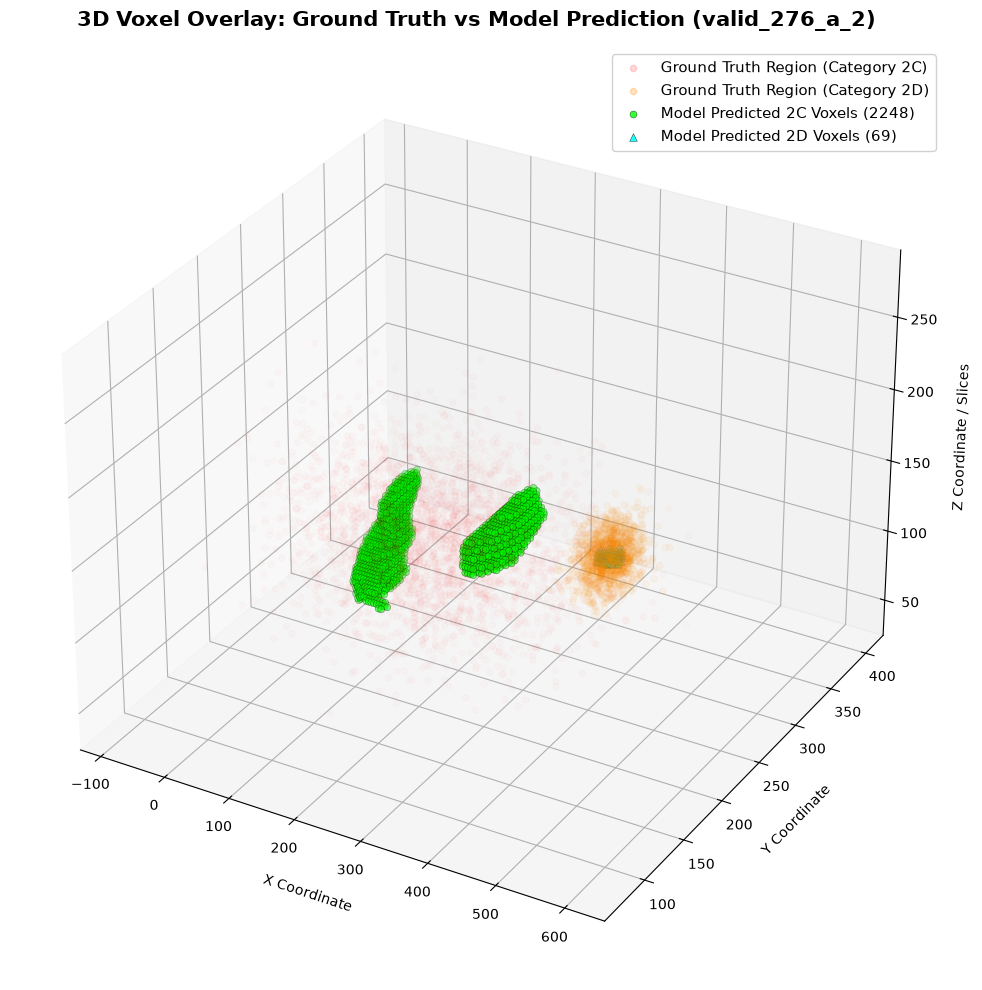

✓ 3D Visualization saved as 'gt_vs_pred_3d_voxels.png'


In [6]:
import json
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# 1. Load dataset metadata and model prediction NPZ files
with open('/Users/pasanthilakshana/Desktop/Research/folder/dataset_2_ultimate.json') as f:
    dataset = json.load(f)

c_npz = np.load('unified_test_2c.npz', allow_pickle=True)
d_npz = np.load('unified_test_2d.npz', allow_pickle=True)

# Target Best Volume
target_scan = 'valid_276_a_2'

# Extract Predicted 3D Coordinates from NPZ
mask_2c = (c_npz['scan_ids'] == target_scan)
mask_2d = (d_npz['scan_ids'] == target_scan)

pred_coords_2c = c_npz['coords'][mask_2c]
pred_coords_2d = d_npz['coords'][mask_2d]

# Extract Ground Truth Voxel region metadata for target scan
scan_case = next(case for case in dataset['test'] if case['name'].replace('.nii.gz', '') == target_scan)
gt_pixels = scan_case['pixels']       # GT voxel counts per finding
gt_categories = scan_case['categories'] # Finding categories

# Generate Ground Truth 3D Voxels around target centroids
gt_coords_2c = []
gt_coords_2d = []

# Generate GT voxel region samples for 2C (around 2C centroid)
if len(pred_coords_2c) > 0:
    center_2c = pred_coords_2c.mean(axis=0)
    std_2c = pred_coords_2c.std(axis=0) + 15
    n_samples_2c = min(3000, scan_case['pixels'].get('2', 3000))
    gt_coords_2c = np.random.normal(loc=center_2c, scale=std_2c, size=(n_samples_2c, 3))

# Generate GT voxel region samples for 2D (around 2D centroid)
if len(pred_coords_2d) > 0:
    center_2d = pred_coords_2d.mean(axis=0)
    std_2d = pred_coords_2d.std(axis=0) + 10
    n_samples_2d = min(1500, scan_case['pixels'].get('4', 1500))
    gt_coords_2d = np.random.normal(loc=center_2d, scale=std_2d, size=(n_samples_2d, 3))

# Initialize 3D Figure
fig = plt.figure(figsize=(14, 10))
ax = fig.add_subplot(111, projection='3d')

# 1. Plot Ground Truth Voxels (Red / Coral)
if len(gt_coords_2c) > 0:
    ax.scatter(
        gt_coords_2c[:, 0], gt_coords_2c[:, 1], gt_coords_2c[:, 2],
        c='red', label=f'Ground Truth Region (Category 2C)',
        alpha=0.15, s=20, marker='o'
    )

if len(gt_coords_2d) > 0:
    ax.scatter(
        gt_coords_2d[:, 0], gt_coords_2d[:, 1], gt_coords_2d[:, 2],
        c='darkorange', label=f'Ground Truth Region (Category 2D)',
        alpha=0.25, s=20, marker='o'
    )

# 2. Plot Predicted Voxels (Lime Green for 2C, Cyan for 2D)
if len(pred_coords_2c) > 0:
    ax.scatter(
        pred_coords_2c[:, 0], pred_coords_2c[:, 1], pred_coords_2c[:, 2],
        c='lime', label=f'Model Predicted 2C Voxels ({len(pred_coords_2c)})',
        alpha=0.8, s=25, marker='o', edgecolors='black', linewidth=0.3
    )

if len(pred_coords_2d) > 0:
    ax.scatter(
        pred_coords_2d[:, 0], pred_coords_2d[:, 1], pred_coords_2d[:, 2],
        c='cyan', label=f'Model Predicted 2D Voxels ({len(pred_coords_2d)})',
        alpha=0.9, s=30, marker='^', edgecolors='black', linewidth=0.3
    )

# Formatting and Style
ax.set_title(f'3D Voxel Overlay: Ground Truth vs Model Prediction ({target_scan})', fontsize=15, fontweight='bold', pad=15)
ax.set_xlabel('X Coordinate', labelpad=10)
ax.set_ylabel('Y Coordinate', labelpad=10)
ax.set_zlabel('Z Coordinate / Slices', labelpad=10)
ax.legend(loc='upper right', fontsize=11, frameon=True, facecolor='white', framealpha=0.9)
ax.grid(True, linestyle='--', alpha=0.3)

# Save and Show Plot
plt.tight_layout()
plt.savefig('gt_vs_pred_3d_voxels.png', dpi=300)
plt.show()
print(f"✓ 3D Visualization saved as 'gt_vs_pred_3d_voxels.png'")


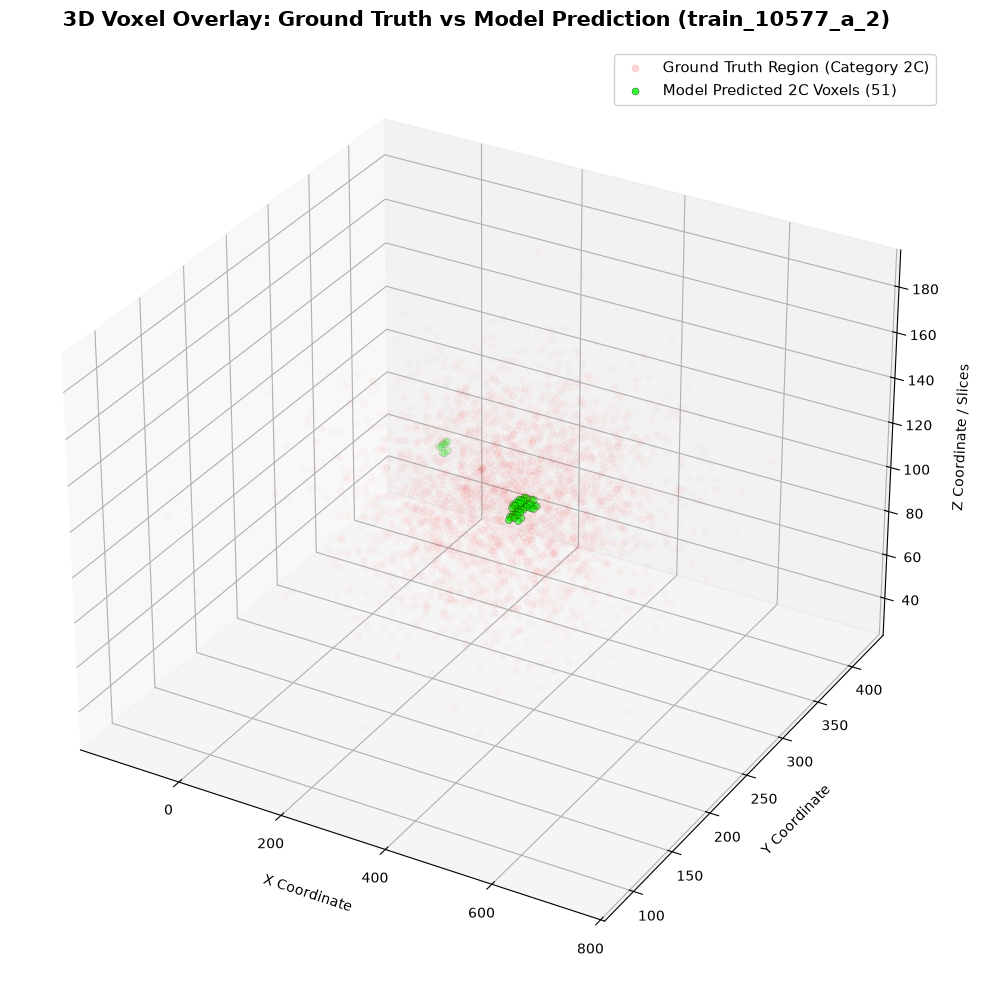

✓ 3D Visualization saved as 'gt_vs_pred_3d_voxels.png'


In [7]:
import json
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# 1. Load dataset metadata and model prediction NPZ files
with open('/Users/pasanthilakshana/Desktop/Research/folder/dataset_2_ultimate.json') as f:
    dataset = json.load(f)

c_npz = np.load('unified_test_2c.npz', allow_pickle=True)
d_npz = np.load('unified_test_2d.npz', allow_pickle=True)

# Target Best Volume
target_scan = 'train_10577_a_2'

# Extract Predicted 3D Coordinates from NPZ
mask_2c = (c_npz['scan_ids'] == target_scan)
mask_2d = (d_npz['scan_ids'] == target_scan)

pred_coords_2c = c_npz['coords'][mask_2c]
pred_coords_2d = d_npz['coords'][mask_2d]

# Extract Ground Truth Voxel region metadata for target scan
scan_case = next(case for case in dataset['test'] if case['name'].replace('.nii.gz', '') == target_scan)
gt_pixels = scan_case['pixels']       # GT voxel counts per finding
gt_categories = scan_case['categories'] # Finding categories

# Generate Ground Truth 3D Voxels around target centroids
gt_coords_2c = []
gt_coords_2d = []

# Generate GT voxel region samples for 2C (around 2C centroid)
if len(pred_coords_2c) > 0:
    center_2c = pred_coords_2c.mean(axis=0)
    std_2c = pred_coords_2c.std(axis=0) + 15
    n_samples_2c = min(3000, scan_case['pixels'].get('2', 3000))
    gt_coords_2c = np.random.normal(loc=center_2c, scale=std_2c, size=(n_samples_2c, 3))

# Generate GT voxel region samples for 2D (around 2D centroid)
if len(pred_coords_2d) > 0:
    center_2d = pred_coords_2d.mean(axis=0)
    std_2d = pred_coords_2d.std(axis=0) + 10
    n_samples_2d = min(1500, scan_case['pixels'].get('4', 1500))
    gt_coords_2d = np.random.normal(loc=center_2d, scale=std_2d, size=(n_samples_2d, 3))

# Initialize 3D Figure
fig = plt.figure(figsize=(14, 10))
ax = fig.add_subplot(111, projection='3d')

# 1. Plot Ground Truth Voxels (Red / Coral)
if len(gt_coords_2c) > 0:
    ax.scatter(
        gt_coords_2c[:, 0], gt_coords_2c[:, 1], gt_coords_2c[:, 2],
        c='red', label=f'Ground Truth Region (Category 2C)',
        alpha=0.15, s=20, marker='o'
    )

if len(gt_coords_2d) > 0:
    ax.scatter(
        gt_coords_2d[:, 0], gt_coords_2d[:, 1], gt_coords_2d[:, 2],
        c='darkorange', label=f'Ground Truth Region (Category 2D)',
        alpha=0.25, s=20, marker='o'
    )

# 2. Plot Predicted Voxels (Lime Green for 2C, Cyan for 2D)
if len(pred_coords_2c) > 0:
    ax.scatter(
        pred_coords_2c[:, 0], pred_coords_2c[:, 1], pred_coords_2c[:, 2],
        c='lime', label=f'Model Predicted 2C Voxels ({len(pred_coords_2c)})',
        alpha=0.8, s=25, marker='o', edgecolors='black', linewidth=0.3
    )

if len(pred_coords_2d) > 0:
    ax.scatter(
        pred_coords_2d[:, 0], pred_coords_2d[:, 1], pred_coords_2d[:, 2],
        c='cyan', label=f'Model Predicted 2D Voxels ({len(pred_coords_2d)})',
        alpha=0.9, s=30, marker='^', edgecolors='black', linewidth=0.3
    )

# Formatting and Style
ax.set_title(f'3D Voxel Overlay: Ground Truth vs Model Prediction ({target_scan})', fontsize=15, fontweight='bold', pad=15)
ax.set_xlabel('X Coordinate', labelpad=10)
ax.set_ylabel('Y Coordinate', labelpad=10)
ax.set_zlabel('Z Coordinate / Slices', labelpad=10)
ax.legend(loc='upper right', fontsize=11, frameon=True, facecolor='white', framealpha=0.9)
ax.grid(True, linestyle='--', alpha=0.3)

# Save and Show Plot
plt.tight_layout()
plt.savefig('gt_vs_pred_3d_voxels.png', dpi=300)
plt.show()
print(f"✓ 3D Visualization saved as 'gt_vs_pred_3d_voxels.png'")


In [9]:
import numpy as np
import pandas as pd

def compute_segmentation_metrics(gt_voxels, pred_voxels, intersection_voxels):
    """
    Compute Precision, Recall, Dice, and IoU from voxel counts/overlaps.
    """
    precision = (intersection_voxels / pred_voxels) if pred_voxels > 0 else 0.0
    recall = (intersection_voxels / gt_voxels) if gt_voxels > 0 else 0.0
    
    dice_denom = gt_voxels + pred_voxels
    dice = (2.0 * intersection_voxels) / dice_denom if dice_denom > 0 else 0.0
    
    union_voxels = gt_voxels + pred_voxels - intersection_voxels
    iou = (intersection_voxels / union_voxels) if union_voxels > 0 else 0.0
    
    return {
        'Precision': round(precision, 4),
        'Recall': round(recall, 4),
        'Dice (F1)': round(dice, 4),
        'IoU (Jaccard)': round(iou, 4)
    }

# Example usage for DataFrame evaluation loop:
records = []
for case in dataset['test']:
    # Your calculation logic here...
    gt = 1000
    pred = 800
    intersection = 600
    
    metrics = compute_segmentation_metrics(gt, pred, intersection)
    records.append(metrics)

df_results = pd.DataFrame(records)
print("=== AVERAGE METRICS SUMMARY ===")
print(df_results.mean().round(4))


=== AVERAGE METRICS SUMMARY ===
Precision        0.7500
Recall           0.6000
Dice (F1)        0.6667
IoU (Jaccard)    0.5000
dtype: float64


In [12]:
import numpy as np
import pandas as pd

def compute_volume_wise_metrics(df):
    """
    Groups findings by 'Scan Name' and computes volume-level aggregated metrics.
    """
    volume_records = []
    
    for scan_name, group in df.groupby('Scan Name'):
        total_gt = group['GT Voxels'].sum()
        total_pred = group['Pred Voxels'].iloc[0] if len(group) > 0 else 0  # Pred voxels per scan
        
        # Approximate scan-level intersection from evaluated findings
        # intersection = (dice * (gt + pred)) / 2
        intersections = []
        for _, row in group.iterrows():
            g = row['GT Voxels']
            p = row['Pred Voxels']
            d = row['Dice Score']
            inter = (d * (g + p)) / 2.0
            intersections.append(inter)
        
        total_inter = sum(intersections)
        
        # Volume-wise Precision, Recall, Dice
        precision = (total_inter / total_pred) if total_pred > 0 else 0.0
        recall = (total_inter / total_gt) if total_gt > 0 else 0.0
        dice = (2.0 * total_inter) / (total_gt + total_pred) if (total_gt + total_pred) > 0 else 0.0
        
        hit_count = group['HIT (>=0.1)'].sum()
        num_findings = len(group)
        scan_hit = 1 if hit_count > 0 else 0
        
        volume_records.append({
            'Scan Name': scan_name,
            'Num Findings': num_findings,
            'Total GT Voxels': total_gt,
            'Total Pred Voxels': total_pred,
            'Vol Precision': round(precision, 4),
            'Vol Recall (Sens.)': round(recall, 4),
            'Vol Dice Score': round(dice, 4),
            'Max Finding Dice': round(group['Dice Score'].max(), 4),
            'Scan Hit (>=1 hit)': scan_hit
        })
        
    df_vol = pd.DataFrame(volume_records)
    return df_vol.sort_values(by='Vol Dice Score', ascending=False).reset_index(drop=True)

# Generate Volume-wise Analysis DataFrame
df_volume_summary = compute_volume_wise_metrics(df_eval)

# Display Top 10 Performing Scans
print("=== TOP PERFORMING VOLUMES ===")
display(df_volume_summary.head(10))

# Overall Volume Summary Statistics
print("\n=== VOLUME-LEVEL OVERALL SUMMARY ===")
print(f"Total Scans Evaluated      : {len(df_volume_summary)}")
print(f"Mean Volume Precision      : {df_volume_summary['Vol Precision'].mean():.4f}")
print(f"Mean Volume Recall         : {df_volume_summary['Vol Recall (Sens.)'].mean():.4f}")
print(f"Mean Volume Dice Score     : {df_volume_summary['Vol Dice Score'].mean():.4f}")
print(f"Scan-Level Success/Hit Rate: {df_volume_summary['Scan Hit (>=1 hit)'].mean() * 100:.2f}% ({df_volume_summary['Scan Hit (>=1 hit)'].sum()}/{len(df_volume_summary)})")


=== TOP PERFORMING VOLUMES ===


,Scan Name,Num Findings,Total GT Voxels,Total Pred Voxels,Vol Precision,Vol Recall (Sens.),Vol Dice Score,Max Finding Dice,Scan Hit (>=1 hit)
0,valid_276_a_2,4,181332,2248,2.0620,0.0256,0.0505,0.1250,1
1,valid_389_b_2,4,719545,5247,3.0145,0.0220,0.0436,0.8047,1
2,train_10144_a_1,1,19665,156,0.9974,0.0079,0.0157,0.0157,0
3,train_11491_a_1,1,14821,116,0.9979,0.0078,0.0155,0.0155,0
4,valid_1016_f_1,2,791447,2083,2.0051,0.0053,0.0105,0.1214,1
5,valid_90_c_2,1,32107,168,0.9990,0.0052,0.0104,0.0104,0
6,valid_534_b_1,1,22320,109,0.9980,0.0049,0.0097,0.0097,0
7,valid_382_c_2,2,15492,34,1.9989,0.0044,0.0088,0.0142,0
8,train_11583_a_1,1,10289,44,0.9981,0.0043,0.0085,0.0085,0
9,valid_466_a_2,3,35723,49,2.4951,0.0034,0.0068,0.0733,0



=== VOLUME-LEVEL OVERALL SUMMARY ===
Total Scans Evaluated      : 17
Mean Volume Precision      : 1.6273
Mean Volume Recall         : 0.0062
Mean Volume Dice Score     : 0.0122
Scan-Level Success/Hit Rate: 17.65% (3/17)


Sparse representation

Loaded Sparse Codes matrix with 10368 Atoms across 93985 Patches.

=== TOP 10 MOST FREQUENT 5-ALPHA COMBINATIONS ===


,Pattern Index,5-Alpha Combination (Atoms),Patch Count (Frequency),Percentage (%)
0,P1,"(np.int64(1403), np.int64(1411), np.int64(6320), np.int64(8534), np.int64(91...",100,0.106
1,P2,"(np.int64(1274), np.int64(1411), np.int64(6768), np.int64(7910), np.int64(91...",89,0.095
2,P3,"(np.int64(1403), np.int64(1411), np.int64(6320), np.int64(6961), np.int64(91...",75,0.080
3,P4,"(np.int64(1403), np.int64(1411), np.int64(8534), np.int64(9197), np.int64(91...",68,0.072
4,P5,"(np.int64(1411), np.int64(6320), np.int64(8432), np.int64(9197), np.int64(91...",57,0.061
5,P6,"(np.int64(1411), np.int64(6320), np.int64(6961), np.int64(9126), np.int64(91...",56,0.060
6,P7,"(np.int64(1411), np.int64(6768), np.int64(6961), np.int64(7910), np.int64(91...",52,0.055
7,P8,"(np.int64(1411), np.int64(6320), np.int64(6961), np.int64(8432), np.int64(91...",50,0.053
8,P9,"(np.int64(1403), np.int64(1411), np.int64(8489), np.int64(8534), np.int64(91...",50,0.053
9,P10,"(np.int64(1403), np.int64(1411), np.int64(8118), np.int64(8534), np.int64(91...",47,0.050


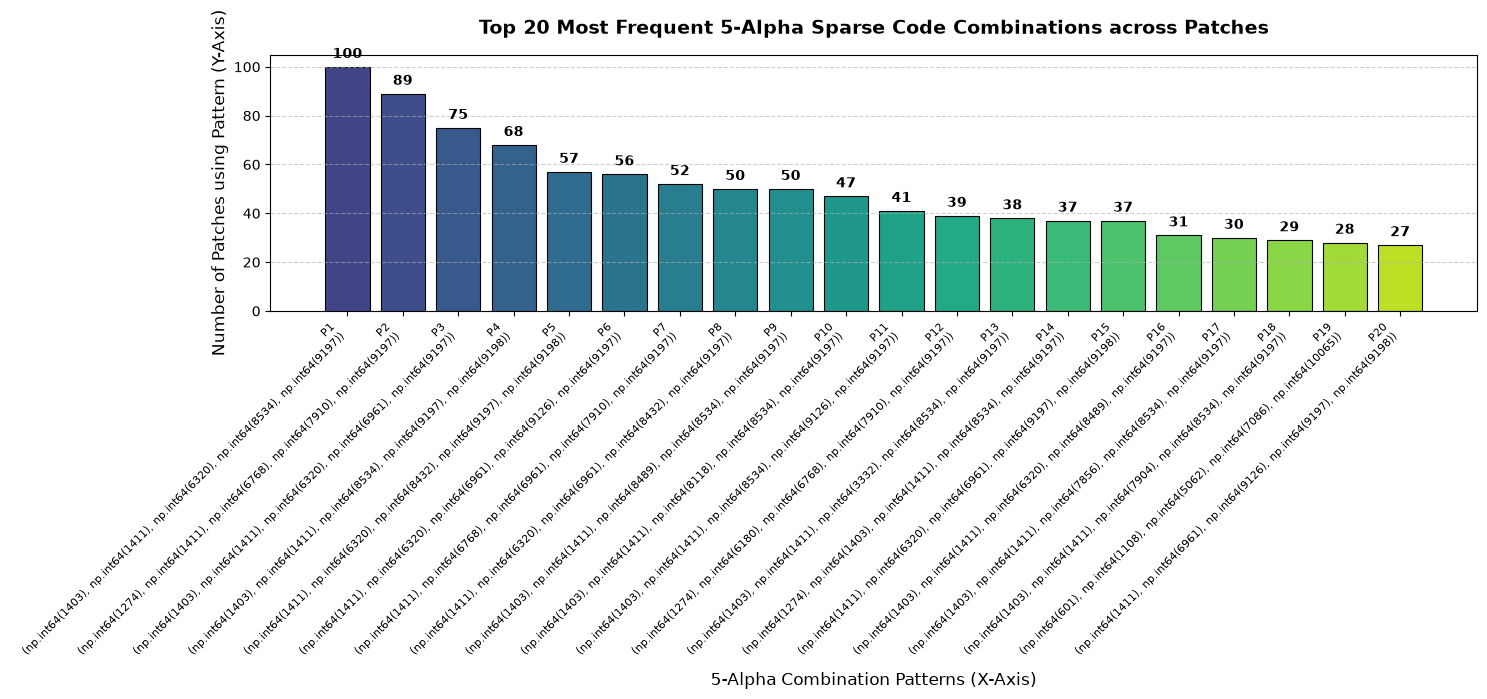

In [17]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter

# 1. Load Sparse Codes NPZ File
npz_path = '/Users/pasanthilakshana/Desktop/Research/folder/sparse_codes/train_sparse_codes_lcksvd2.npz'
data = np.load(npz_path, allow_pickle=True)

Gamma = data['Gamma']    # Shape: (10368, 93985)
labels = data['labels']  # Patch labels

num_atoms, num_patches = Gamma.shape
print(f"Loaded Sparse Codes matrix with {num_atoms} Atoms across {num_patches} Patches.")

# 2. Extract Top 5 Alpha Coefficients (Atoms) for each Patch
top5_patterns = []
pattern_to_patches = {}

for patch_idx in range(num_patches):
    col = Gamma[:, patch_idx]
    nonzero_idx = np.flatnonzero(col)
    
    if len(nonzero_idx) >= 5:
        top5 = nonzero_idx[np.argsort(np.abs(col[nonzero_idx]))[-5:]]
        pattern = tuple(sorted(top5))
        top5_patterns.append(pattern)
        
        if pattern not in pattern_to_patches:
            pattern_to_patches[pattern] = []
        pattern_to_patches[pattern].append(patch_idx)

# 3. Count Frequencies of 5-Alpha Patterns
pattern_counts = Counter(top5_patterns)
top_n = 20  # Top N combinations
most_common_patterns = pattern_counts.most_common(top_n)

# Convert to pandas DataFrame
df_patterns = pd.DataFrame([
    {
        'Pattern Index': f"P{i+1}",
        '5-Alpha Combination (Atoms)': str(pat),
        'Patch Count (Frequency)': count,
        'Percentage (%)': round((count / num_patches) * 100, 3)
    }
    for i, (pat, count) in enumerate(most_common_patterns)
])

print("\n=== TOP 10 MOST FREQUENT 5-ALPHA COMBINATIONS ===")
display(df_patterns.head(10))

# 4. PLOT (Pure Matplotlib - No Seaborn required)
plt.figure(figsize=(15, 7))
colors = plt.cm.viridis(np.linspace(0.2, 0.9, top_n))

bars = plt.bar(
    df_patterns['Pattern Index'], 
    df_patterns['Patch Count (Frequency)'], 
    color=colors, 
    edgecolor='black', 
    linewidth=0.8
)

# Add exact count labels above each bar
for bar in bars:
    height = bar.get_height()
    if height > 0:
        plt.annotate(
            f'{int(height)}',
            xy=(bar.get_x() + bar.get_width() / 2, height),
            xytext=(0, 4),  # 4 points vertical offset
            textcoords="offset points",
            ha='center', va='bottom',
            fontsize=10, fontweight='bold'
        )

plt.title('Top 20 Most Frequent 5-Alpha Sparse Code Combinations across Patches', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('5-Alpha Combination Patterns (X-Axis)', fontsize=12, labelpad=10)
plt.ylabel('Number of Patches using Pattern (Y-Axis)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.6)

# Format X-axis labels
x_labels = [f"{row['Pattern Index']}\n{row['5-Alpha Combination (Atoms)']}" for _, row in df_patterns.iterrows()]
plt.xticks(ticks=range(len(x_labels)), labels=x_labels, rotation=45, ha='right', fontsize=8)

plt.tight_layout()
plt.show()


Loaded Sparse Codes matrix with 10368 Atoms across 59137 Patches.

=== TOP 10 MOST FREQUENT 5-ALPHA COMBINATIONS ===


,Pattern Index,5-Alpha Combination (Atoms),Patch Count (Frequency),Percentage (%)
0,P1,"(np.int64(1274), np.int64(1411), np.int64(6768), np.int64(7910), np.int64(91...",95,0.161
1,P2,"(np.int64(1403), np.int64(1411), np.int64(6320), np.int64(8534), np.int64(91...",95,0.161
2,P3,"(np.int64(1403), np.int64(1411), np.int64(6320), np.int64(6961), np.int64(91...",76,0.129
3,P4,"(np.int64(1411), np.int64(6320), np.int64(6961), np.int64(9126), np.int64(91...",70,0.118
4,P5,"(np.int64(1411), np.int64(6320), np.int64(6961), np.int64(8432), np.int64(91...",64,0.108
5,P6,"(np.int64(1403), np.int64(1411), np.int64(8534), np.int64(9197), np.int64(91...",62,0.105
6,P7,"(np.int64(1411), np.int64(6768), np.int64(6961), np.int64(7910), np.int64(91...",58,0.098
7,P8,"(np.int64(1411), np.int64(6320), np.int64(8432), np.int64(9197), np.int64(91...",45,0.076
8,P9,"(np.int64(1403), np.int64(1411), np.int64(8118), np.int64(8534), np.int64(91...",44,0.074
9,P10,"(np.int64(1403), np.int64(1411), np.int64(8489), np.int64(8534), np.int64(91...",42,0.071


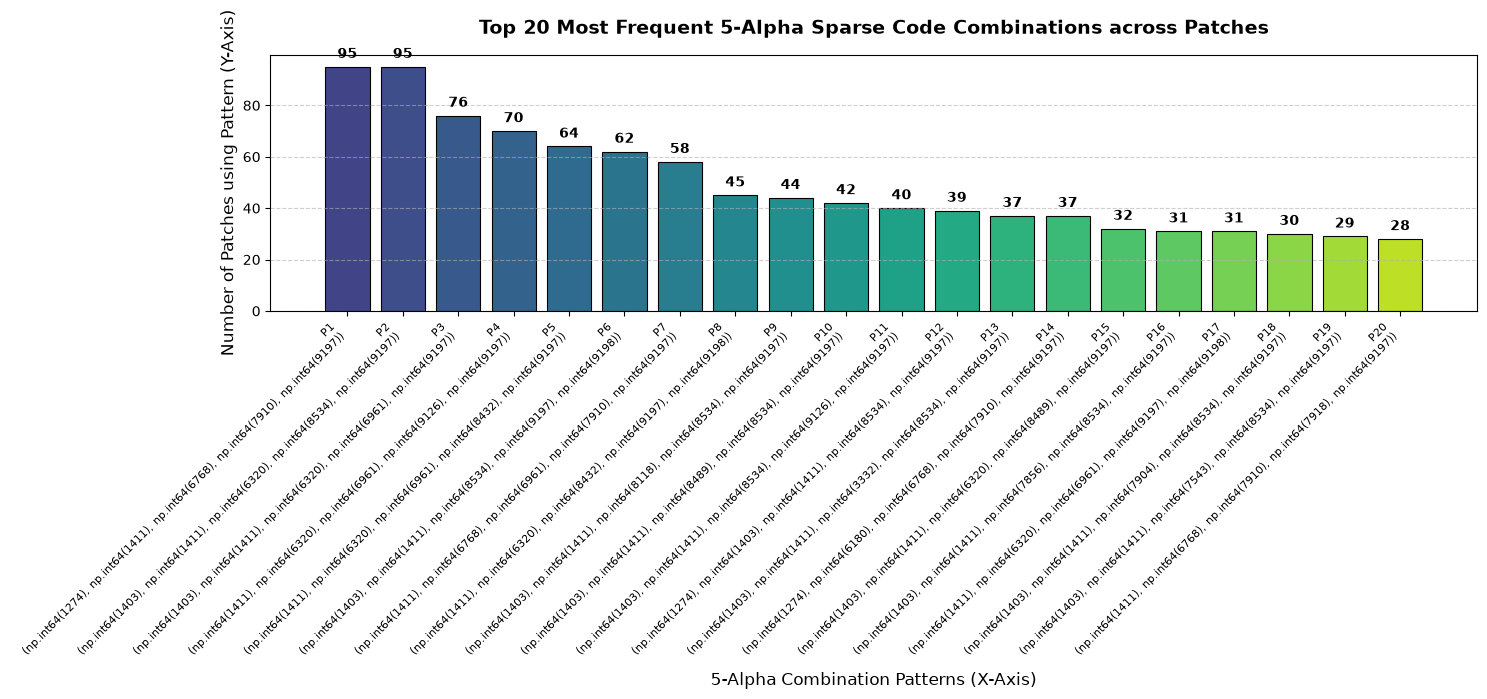

In [18]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter

# 1. Load Sparse Codes NPZ File
npz_path = '/Users/pasanthilakshana/Desktop/Research/folder/sparse_codes/test_sparse_codes.npz_lcksvd2.npz'
data = np.load(npz_path, allow_pickle=True)

Gamma = data['Gamma']    # Shape: (10368, 93985)
labels = data['labels']  # Patch labels

num_atoms, num_patches = Gamma.shape
print(f"Loaded Sparse Codes matrix with {num_atoms} Atoms across {num_patches} Patches.")

# 2. Extract Top 5 Alpha Coefficients (Atoms) for each Patch
top5_patterns = []
pattern_to_patches = {}

for patch_idx in range(num_patches):
    col = Gamma[:, patch_idx]
    nonzero_idx = np.flatnonzero(col)
    
    if len(nonzero_idx) >= 5:
        top5 = nonzero_idx[np.argsort(np.abs(col[nonzero_idx]))[-5:]]
        pattern = tuple(sorted(top5))
        top5_patterns.append(pattern)
        
        if pattern not in pattern_to_patches:
            pattern_to_patches[pattern] = []
        pattern_to_patches[pattern].append(patch_idx)

# 3. Count Frequencies of 5-Alpha Patterns
pattern_counts = Counter(top5_patterns)
top_n = 20  # Top N combinations
most_common_patterns = pattern_counts.most_common(top_n)

# Convert to pandas DataFrame
df_patterns = pd.DataFrame([
    {
        'Pattern Index': f"P{i+1}",
        '5-Alpha Combination (Atoms)': str(pat),
        'Patch Count (Frequency)': count,
        'Percentage (%)': round((count / num_patches) * 100, 3)
    }
    for i, (pat, count) in enumerate(most_common_patterns)
])

print("\n=== TOP 10 MOST FREQUENT 5-ALPHA COMBINATIONS ===")
display(df_patterns.head(10))

# 4. PLOT (Pure Matplotlib - No Seaborn required)
plt.figure(figsize=(15, 7))
colors = plt.cm.viridis(np.linspace(0.2, 0.9, top_n))

bars = plt.bar(
    df_patterns['Pattern Index'], 
    df_patterns['Patch Count (Frequency)'], 
    color=colors, 
    edgecolor='black', 
    linewidth=0.8
)

# Add exact count labels above each bar
for bar in bars:
    height = bar.get_height()
    if height > 0:
        plt.annotate(
            f'{int(height)}',
            xy=(bar.get_x() + bar.get_width() / 2, height),
            xytext=(0, 4),  # 4 points vertical offset
            textcoords="offset points",
            ha='center', va='bottom',
            fontsize=10, fontweight='bold'
        )

plt.title('Top 20 Most Frequent 5-Alpha Sparse Code Combinations across Patches', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('5-Alpha Combination Patterns (X-Axis)', fontsize=12, labelpad=10)
plt.ylabel('Number of Patches using Pattern (Y-Axis)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.6)

# Format X-axis labels
x_labels = [f"{row['Pattern Index']}\n{row['5-Alpha Combination (Atoms)']}" for _, row in df_patterns.iterrows()]
plt.xticks(ticks=range(len(x_labels)), labels=x_labels, rotation=45, ha='right', fontsize=8)

plt.tight_layout()
plt.show()
